In [1]:
# !uv pip install numpy quantities matplotlib scipy neo nixio pyocclient tqdm

In [2]:
!uv pip install neo

Using Python 3.12.13 environment at: /usr
Resolved 4 packages in 724ms
Prepared 2 packages in 236ms
Installed 2 packages in 5ms
 + neo==0.14.5
 + quantities==0.16.4


In [3]:
!uv pip install NixIO

Using Python 3.12.13 environment at: /usr
Resolved 4 packages in 2.63s
Prepared 1 package in 494ms
Installed 1 package in 4ms
 + nixio==1.5.4


<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/NI-Day2-Data-Models/blob/main/03_working_with_datasets_in_neo/03_exercises.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Neo (Part 2): Organizing Electrophysiology Data

In the first session you worked with the Neo data objects `AnalogSignal`, `SpikeTrain`, `Event`, `Epoch`. In this session, you will learn how to organise these data objects into containers called `Block` and `Segment` for a complete, trial-based dataset, much like one you would obtain by loading a recording from disk.

You will also get practice exploring the contents of a dataset, select subsets of the data using metadata, cut the recording into per-trial segments with Neo's utility functions, and finally transform and visualise a signal.

## Setup

### Import Libraries

In [4]:
import neo
import numpy as np
import quantities as pq
import matplotlib.pyplot as plt

from neo.utils import add_epoch, cut_segment_by_epoch, get_events
from neo.core.filters import IsNot, IsIn, GreaterThan, LessThan, GreaterThanOrEquals, LessThanOrEquals, InRange

### Generate Data

Please run the following cell, which will generate a data file that we will use later.

In [5]:
from pathlib import Path

rng = np.random.default_rng(0)

# A 96-channel LFP-like signal sampled at 1 kHz for 10 s.
lfp = neo.AnalogSignal(rng.normal(size=(10000, 96)), units='uV',
                       sampling_rate=1000*pq.Hz, t_start=0*pq.s,
                       name='LFP')
lfp.array_annotate(channel_names=np.array([f'chan{i+1}' for i in range(96)]))

# A smaller 6-channel signal sampled at 30 kHz for 10 s.
hires = neo.AnalogSignal(rng.normal(size=(300000, 6)), units='uV',
                         sampling_rate=30000*pq.Hz, t_start=0*pq.s,
                         name='Subsample unprocessed signal')
hires.array_annotate(channel_names=np.array([f'ainp{i+1}' for i in range(6)]))

# A handful of spike trains, each labelled as single-unit, multi-unit or noise.
unit_types = ['sua', 'mua', 'noise', 'sua', 'mua', 'sua', 'noise', 'sua']
spiketrains = []
for i, unit_type in enumerate(unit_types):
    times = np.sort(rng.uniform(0, 10, size=rng.integers(50, 150)))
    st = neo.SpikeTrain(times*pq.s, t_start=0*pq.s, t_stop=10*pq.s, name=f'unit {i}')
    st.annotate(unit_type=unit_type)
    spiketrains.append(st)

# Trial-start events, alternating correct and error, every 3 s.
ts_times = np.arange(1, 10, 3) * pq.s
performance = np.array(['correct_trial' if i % 2 == 0 else 'error_trial'
                        for i in range(len(ts_times))])
events = neo.Event(ts_times, labels=np.array(['TS-ON'] * len(ts_times)),
                   name='TrialEvents')
events.array_annotate(performance_in_trial_str=performance)

# Assemble everything into a Block with one Segment.
segment = neo.Segment(name='recording')
segment.analogsignals.extend([lfp, hires])
segment.spiketrains.extend(spiketrains)
segment.events.append(events)
block = neo.Block(name='dataset')
block.segments.append(segment)

# Write the block to a NIX file that the notebook reads back in.
out_path = Path('dataset.nix')
out_path.unlink(missing_ok=True)
with neo.NixIO(str(out_path), mode='ow') as io:
    io.write_block(block)
print(f'Wrote dataset to {out_path}')

Wrote dataset to dataset.nix


## Organizing Data: `Block` and `Segment`

### Background

A real recording often contains several of the data objects `AnalogSignal`, `SpikeTrain`, `Event`, `Epoch`, and Neo organises them in a simple two-level hierarchy:

- A **`Segment`** holds all data objects that share a common clock — for example everything recorded during a single trial or a single continuous recording. Its data is stored in lists: `segment.analogsignals`, `segment.spiketrains`, `segment.events`, and `segment.epochs`.
- A **`Block`** is the top-level container that holds everything; its `block.segments` list holds one or more segments.

Once data is organised this way, the `filter` method lets you search a block (or segment) for all objects of a given type or with a given annotation, without walking the hierarchy by hand.

### Exercises

In this section you will build a `Block` containing a `Segment`, add data objects to it, navigate the hierarchy, and search it with `filter`.

| Code | Description |
| :-- | :-- |
| `neo.Block(name='my block')` | Create a block (the top-level container). |
| `neo.Segment(name='trial 1')` | Create a segment (a group of data with a shared clock). |
| `block.segments.append(seg)` | Add a segment to a block. |
| `neo.AnalogSignal(np.random.random((100, 4)), units='uV', sampling_rate=1000*pq.Hz)` | Create an `AnalogSignal` from a NumPy array, units, and a sampling rate. |
| `seg.analogsignals.append(sig)` | Add an `AnalogSignal` to a segment. |
| `neo.SpikeTrain([0.1, 0.4, 0.8], units='s', t_start=0*pq.s, t_stop=1*pq.s)` | Create a `SpikeTrain` from a list of spike times. |
| `seg.spiketrains.append(st)` | Add a `SpikeTrain` to a segment. |
| `obj.annotate(key=value)` | Attach a named annotation to any Neo object. |
| `print(seg.spiketrains)` | Display the list of spike trains in a segment. |
| `block.filter(objects=neo.AnalogSignal)` | Find all analog signals anywhere in the block. |
| `block.filter(objects=neo.SpikeTrain)` | Find all spike trains anywhere in the block. |

**Example**: Create a block named `example block` containing one segment named `example segment`. Dissplay the block.

In [6]:
block = neo.Block(name='my block')
seg = neo.Segment(name='trial 1')
block.segments.append(seg)
block

Block with [<neo.core.segment.Segment object at 0x7d6f34faaf30>] segments
name: 'my block'
# segments (N=[<neo.core.segment.Segment object at 0x7d6f34faaf30>])
0: Segment with  name: 'trial 1' # analogsignals (N=[])

Add an `AnalogSignal` with `100` samples in `4` different channels with units `uV` and sampling rate `1000 Hz` to that segment. Display the block container to check that the segment now has the `AnalogSignal` object.

In [7]:
sig = neo.AnalogSignal(np.random.random((100, 4)), units='uV', sampling_rate=1000*pq.Hz)
seg.analogsignals.append(sig)
block

Block with [<neo.core.segment.Segment object at 0x7d6f34faaf30>] segments
name: 'my block'
# segments (N=[<neo.core.segment.Segment object at 0x7d6f34faaf30>])
0: Segment with [<AnalogSignal(array([[0.04496285, 0.1665311 , 0.1107835 , 0.17419688],
       [0.58177633, 0.10826085, 0.6830398 , 0.8366129 ],
       [0.45316384, 0.87530891, 0.09666918, 0.785647  ],
       [0.63703386, 0.85375745, 0.08780742, 0.4532223 ],
       [0.70350721, 0.03719823, 0.25913384, 0.51564582],
       [0.31827178, 0.25043113, 0.20827063, 0.82157787],
       [0.89271584, 0.3164257 , 0.77230629, 0.60159149],
       [0.24198238, 0.30082848, 0.27944539, 0.37158447],
       [0.67285287, 0.57815666, 0.84175734, 0.59741326],
       [0.18126824, 0.3768457 , 0.78533779, 0.91293907],
       [0.0541277 , 0.93561617, 0.59719644, 0.62047777],
       [0.90206771, 0.38765753, 0.40830805, 0.7326882 ],
       [0.6894404 , 0.82265402, 0.44652771, 0.87929599],
       [0.52767036, 0.46736719, 0.64271988, 0.57273122],
       [0.4

**Exercise**: Create a new block named `'block1'` and store it in a variable `block1`. Add one segment named `'trial 1'` to it. Display `block1`.

In [8]:
block = neo.Block(name='block1')
seg = neo.Segment(name='trial 1')
block.segments.append(seg)
block

Block with [<neo.core.segment.Segment object at 0x7d6f34faad80>] segments
name: 'block1'
# segments (N=[<neo.core.segment.Segment object at 0x7d6f34faad80>])
0: Segment with  name: 'trial 1' # analogsignals (N=[])

Add an `AnalogSignal` with `20` samples in `8` different channels with units `mV` and sampling rate `30 kHz` to that segment. Display the block container to check that the segment has the `AnalogSignal` object.

In [9]:
sig = neo.AnalogSignal(np.random.random((20, 8)), units='mV', sampling_rate=30000*pq.Hz)
seg.analogsignals.append(sig)
block

Block with [<neo.core.segment.Segment object at 0x7d6f34faad80>] segments
name: 'block1'
# segments (N=[<neo.core.segment.Segment object at 0x7d6f34faad80>])
0: Segment with [<AnalogSignal(array([[0.64483201, 0.59477867, 0.02673588, 0.49591917, 0.9336653 ,
        0.68230695, 0.19031127, 0.40480013],
       [0.59565013, 0.7139397 , 0.51762107, 0.08923376, 0.58149753,
        0.89411403, 0.92580723, 0.87487805],
       [0.17308762, 0.45059629, 0.63032583, 0.45588884, 0.48609777,
        0.53942836, 0.61787004, 0.3171318 ],
       [0.90151682, 0.08010105, 0.67885744, 0.78143245, 0.71348317,
        0.15383872, 0.72732042, 0.35673173],
       [0.72801706, 0.25384977, 0.70038909, 0.15656096, 0.31478755,
        0.83371842, 0.94987327, 0.60767476],
       [0.40062696, 0.65824827, 0.35009666, 0.04002811, 0.86957341,
        0.16950062, 0.80872452, 0.09234187],
       [0.47795144, 0.51868991, 0.76466654, 0.51065929, 0.45716433,
        0.02505424, 0.15685853, 0.66284712],
       [0.64684852, 

**Exercise**: Add a `SpikeTrain` object containing the timestamps `[0.1, 0.4, 0.8]` to the segment's `spiketrains` list, annotated with `unit_id=0`. Display the spiketrains of the segment using `print`.

In [10]:
neo.SpikeTrain([0.1, 0.4, 0.8], units='s', t_start=0*pq.s, t_stop=1*pq.s)
seg.spiketrains.append(st)
print(seg.spiketrains)

[<SpikeTrain(array([0.06469192, 0.10621435, 0.14154379, 0.19332316, 0.28984526,
       0.34958026, 0.364381  , 0.39874483, 0.50729933, 0.56298177,
       0.69522629, 0.71105398, 0.7151176 , 0.7768351 , 0.7946275 ,
       0.93947359, 0.96344243, 1.03534031, 1.04539714, 1.14798385,
       1.34405908, 1.5897129 , 1.6231431 , 1.76306627, 1.77072373,
       1.81933989, 1.82969342, 1.96714655, 1.99501775, 2.03345332,
       2.15656138, 2.2158512 , 2.51266078, 2.54962876, 2.61250014,
       2.64346183, 2.82561236, 2.92800557, 3.24000507, 3.26651816,
       3.27093769, 3.27904108, 3.28481952, 3.28554356, 3.45102684,
       3.48882028, 3.55280674, 3.59327492, 3.66418642, 3.99401233,
       4.04496238, 4.20644363, 4.4041731 , 4.40495947, 4.43598122,
       4.46290522, 4.47499591, 4.49022684, 4.50906266, 4.76277785,
       4.78698295, 4.84478462, 4.90564363, 4.91468169, 4.97970451,
       5.15321067, 5.2256521 , 5.34687545, 5.52877281, 5.66724245,
       5.70456178, 5.7337321 , 5.80289466, 6.1378

**Exercise**: Add another `SpikeTrain` object containing the timestamps `[0.2, 0.6]` to the segment's `spiketrains` list, annotated with `unit_id=1`. Print the segment spiketrains to see that it now contains both spike trains.

In [11]:
stnew = neo.SpikeTrain([0.2, 0.6], units='s', t_start=0*pq.s, t_stop=1*pq.s, unit_id=1)
seg.spiketrains.append(stnew)
print(seg.spiketrains)

[<SpikeTrain(array([0.06469192, 0.10621435, 0.14154379, 0.19332316, 0.28984526,
       0.34958026, 0.364381  , 0.39874483, 0.50729933, 0.56298177,
       0.69522629, 0.71105398, 0.7151176 , 0.7768351 , 0.7946275 ,
       0.93947359, 0.96344243, 1.03534031, 1.04539714, 1.14798385,
       1.34405908, 1.5897129 , 1.6231431 , 1.76306627, 1.77072373,
       1.81933989, 1.82969342, 1.96714655, 1.99501775, 2.03345332,
       2.15656138, 2.2158512 , 2.51266078, 2.54962876, 2.61250014,
       2.64346183, 2.82561236, 2.92800557, 3.24000507, 3.26651816,
       3.27093769, 3.27904108, 3.28481952, 3.28554356, 3.45102684,
       3.48882028, 3.55280674, 3.59327492, 3.66418642, 3.99401233,
       4.04496238, 4.20644363, 4.4041731 , 4.40495947, 4.43598122,
       4.46290522, 4.47499591, 4.49022684, 4.50906266, 4.76277785,
       4.78698295, 4.84478462, 4.90564363, 4.91468169, 4.97970451,
       5.15321067, 5.2256521 , 5.34687545, 5.52877281, 5.66724245,
       5.70456178, 5.7337321 , 5.80289466, 6.1378

**Exercise**: Use `filter` to get a list of all `AnalogSignal` objects in the block.

In [12]:
block.filter(objects=neo.AnalogSignal)

[AnalogSignal with 8 channels of length 20; units mV; datatype float64
 sampling rate: 30000.0 Hz
 time: 0.0 s to 0.0006666666666666666 s]

**Exercise**: Use `filter` to get a list of all `SpikeTrain` objects in the block, and report how many there are.

In [13]:
block.filter(objects=neo.SpikeTrain)

<SpikeTrainList>

In [14]:
len(block.filter(objects=neo.SpikeTrain))

2

## Exploring a Dataset

### Background

When you load a recording, the first thing to do is find out what it contains: how many continuous recording parts (segments) there are, how many channels were recorded and at what sampling rates, and how many spike trains are present. The `Block` and `Segment` objects expose this through their lists (`block.segments`, `segment.analogsignals`, `segment.spiketrains`, `segment.events`), and the `filter` method lets you select objects by type or by annotation.

### Exercises

In this section you will inspect the structure of `block`, read off the properties of its signals, and use annotations to select a meaningful subset of the spike trains.

| Code | Description |
| :-- | :-- |
| `block` | Print a summary of a block and its contents. |
| `block.segments` | The list of segments in the block. |
| `len(block.segments)` | The number of segments in the block. |
| `segment = block.segments[0]` | Access the first (here, only) segment. |
| `segment.analogsignals` | The list of `AnalogSignal` objects in a segment. |
| `sig.name`, `sig.shape`, `sig.sampling_rate` | Properties of an `AnalogSignal`. |
| `segment.spiketrains` | The list of `SpikeTrain` objects in a segment. |
| `len(segment.spiketrains)` | The number of spike trains in a segment. |
| `block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'sua'})` | Find all spike trains with a given annotation. |

**The Dataset**

Run the cell below to load the dataset used for the rest of this notebook from the NIX file in the `data` folder. It contains a single `Block` with one `Segment` that contains:

- two `AnalogSignal` objects, both spanning 10 s: a 96-channel LFP-like signal sampled at 1 kHz, and a smaller 6-channel signal sampled at 30 kHz, each with per-channel `channel_names`;
- a set of `SpikeTrain` objects, each annotated as `'sua'`, `'mua'`, or `'noise'`;
- an `Event` object marking trial-start (`TS-ON`) times, with a per-event annotation recording whether each trial was a `'correct_trial'` or an `'error_trial'`.

This is the kind of structure you obtain when loading a real recording from disk.

In [15]:
with neo.NixIO('dataset.nix', mode='ro') as io:
    block = io.read_block()
block

Block with [<neo.core.segment.Segment object at 0x7d6f34fa2f30>] segments
name: 'dataset'
annotations: {'nix_name': 'neo.block.0d83ec5461364701ac6b3a11dcfa00f4'}
rec_datetime: datetime.datetime(2026, 7, 4, 21, 41, 1)
# segments (N=[<neo.core.segment.Segment object at 0x7d6f34fa2f30>])
0: Segment with [<AnalogSignal(array([[ 0.12573022, -0.13210486,  0.64042265, ..., -0.73548329,
         0.24978537,  1.03145308],
       [ 0.16100958, -0.58552882, -1.34121971, ..., -0.47433299,
        -1.94426498, -1.3077532 ],
       [ 1.08683078, -0.05060406, -0.28312507, ...,  0.11566183,
        -1.07054441, -1.0026843 ],
       ...,
       [ 0.55947905,  0.18952103, -0.67187467, ..., -0.05874888,
        -0.11022754, -1.18243894],
       [-0.73628695, -1.45294563,  0.08538314, ..., -0.25738861,
         2.05335138,  2.77651512],
       [ 1.06179533, -0.97950888, -0.9572926 , ..., -1.33537531,
        -0.5644885 ,  1.39068265]]) * uV, [0.0 s, 10.0 s], sampling rate: 1000.0 Hz)>, <AnalogSignal(array

**Exercise**: How many segments does the block contain? Hint: use `len`.

In [16]:
len(block.segments)

1

**Exercise**: Assign the first segment to a variable `segment`. How many `AnalogSignal` objects does the segment contain?

In [17]:
segment = block.segments[0]

In [18]:
len(segment.analogsignals)

2

**Exercise**: For the first `AnalogSignal` in the segment, print its name, shape and sampling rate.

In [19]:
first_sig = segment.analogsignals[0]
print(first_sig.name)
print(first_sig.shape)
print(first_sig.sampling_rate)

LFP
(10000, 96)
1000.0 Hz


**Exercise**: For the second `AnalogSignal` in the segment, print its name, shape and sampling rate. Which of the two signals has the higher temporal resolution?

In [20]:
second_sig = segment.analogsignals[1]
print(second_sig.name)
print(second_sig.shape)
print(second_sig.sampling_rate)

Subsample unprocessed signal
(300000, 6)
30000.0 Hz


the second one has the higher temporal resolution.

**Exercise**: How many `SpikeTrain` objects does the segment contain?

In [21]:
len(segment.spiketrains)

8

**Exercise**: Use `filter` to get all spike trains annotated as single-unit activity (`unit_type` equal to `'sua'`), and report how many there are.

In [22]:
block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'sua'})

<SpikeTrainList>

In [23]:
len(block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'sua'}))

4

**Exercise**: Use `filter` to get all spike trains annotated as multi-unit activity (`unit_type` equal to `'mua'`), and report how many there are.

In [24]:
block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'mua'})

<SpikeTrainList>

In [25]:
len(block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'mua'}))

2

**Exercise**: Use `filter` to get all spike trains annotated as noise (`unit_type` equal to `'noise'`). How many noise spike trains does the block contain?

In [26]:
block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'noise'})

<SpikeTrainList>

In [27]:
len(block.filter(objects=neo.SpikeTrain, targdict={'unit_type': 'noise'}))

2

The exact-value `targdict` matching used above works well for equality tests, but Neo also supports `FilterCondition` objects from `neo.core.filters` that express richer queries — inequality tests and set membership — directly inside `block.filter()` without needing a separate list comprehension.

| Condition | Description |
| --- | --- |
| `IsNot(x)` | annotation **≠** x |
| `IsIn([a, b])` | annotation is one of a, b |

**Exercise**: Use `block.filter()` with `IsNot('noise')` on the `unit_type` annotation to retrieve all spike trains that are **not** noise in a single call. Print how many are returned, and compare with the sum of the SUA and MUA counts found earlier.

In [28]:
block.filter(objects=neo.SpikeTrain, targdict={'unit_type': IsNot('noise')})

<SpikeTrainList>

In [29]:
len(block.filter(objects=neo.SpikeTrain, targdict={'unit_type': IsNot('noise')}))

6

**Exercise**: Use `IsIn(['sua', 'mua'])` to retrieve all spike trains whose `unit_type` is either `'sua'` or `'mua'` in one call. Confirm the result is the same as the `IsNot('noise')` query above.

In [30]:
block.filter(objects=neo.SpikeTrain, targdict={'unit_type': IsIn(['sua', 'mua'])})

<SpikeTrainList>

In [31]:
len(block.filter(objects=neo.SpikeTrain, targdict={'unit_type': IsIn(['sua', 'mua'])}))

6

The equality and membership conditions used above (`IsNot`, `IsIn`) are useful for string annotations. When annotations carry **numeric** values, Neo's `filter` also supports inequality and range conditions from `neo.core.filters`:

| Condition | Description |
| --- | --- |
| `GreaterThan(x)` | annotation value **>** x |
| `LessThan(x)` | annotation value **<** x |
| `GreaterThanOrEquals(x)` | annotation value **≥** x |
| `LessThanOrEquals(x)` | annotation value **≤** x |
| `InRange(lo, hi)` | lo **≤** value **≤** hi |

These conditions are passed as values in `targdict`, e.g. `block.filter(objects=neo.SpikeTrain, targdict={'unit_id': GreaterThan(3)})`.

**Exercise**: Add four more empty `SpikeTrain` objects (`t_stop=1*pq.s`) to `block1`'s segment (which already has two spike trains attached from a previous exercise), annotated with `unit_id` from 2 to 5. Then use `GreaterThan(3)` to retrieve all spike trains in `block1` whose `unit_id` is strictly greater than 3. Print the `unit_id` annotation of each returned spike train.

In [32]:
for i in range(2, 6):
    st = neo.SpikeTrain([] * pq.s, t_stop=1 * pq.s, unit_id=i)
    block.segments[0].spiketrains.append(st)

In [33]:
filtered_spiketrains = block.filter(objects=neo.SpikeTrain, unit_id=GreaterThan(3))

In [34]:
for st in filtered_spiketrains:
    print(st.annotations['unit_id'])

4
5


**Exercise**: Use `InRange(1, 3)` to retrieve all spike trains in `block1` whose `unit_id` lies between 1 and 3 (bounds inclusive). Print the matching `unit_id` values and confirm the count.

In [35]:
for st in block.filter(objects=neo.SpikeTrain, unit_id=InRange(1, 3)):
    print(st.annotations['unit_id'])

2
3


## Selecting and Masking Data

### Background

Analysis usually focuses on a subset of the data: certain channels, certain trials, or a certain time window. Neo gives you several complementary ways to slice data out of an object:

- **Boolean masks on array annotations** select the events (or channels) whose metadata satisfies a condition. A mask is a boolean array you build by comparing an array annotation to a value. Indexing an `Event` with a mask returns a new `Event` with just those time points.
- **Column slicing** (`sig[:, indices]`) selects channels of an `AnalogSignal`.
- **`time_slice(t_start, t_stop)`** returns a new object containing only the data in a time window, and works on signals, spike trains, and whole segments.

### Exercises

In this section you will select events from correct trials with a mask, pick out a range of channels, and extract a time window of a signal.

| Code | Description |
| :-- | :-- |
| `segment.events[0]` | Access the first `Event` object in a segment. |
| `ev.array_annotations['performance_in_trial_str']` | Read a per-event array annotation. |
| `mask = ev.array_annotations['key'] == 'value'` | Build a boolean mask from a condition. |
| `ev[mask]` | Select the events where the mask is `True`. |
| `len(events)` | The number of time points in an `Event`. |
| `sig[:, 10:20]` | Select a range of channels (columns) of a signal. |
| `sig.shape` | The shape of the underlying data array. |
| `sig.array_annotations['channel_names']` | Read the names of the channels. |
| `sig.time_slice(5*pq.s, 6*pq.s)` | Extract the data between two time points. |

**Example**: The segment's `Event` object marks trial starts. Build a mask selecting only the events from correct trials, and use it to create a new `Event` containing just those time points. `performance_in_trial_str` is an array annotation that shows, for each individual event contained within the object, a string indicating the performance of the trial during which the event was recorded.

In [36]:
events = segment.events[0]
mask = events.array_annotations['performance_in_trial_str'] == 'correct_trial'
correct_events = events[mask]
correct_events

Event containing 2 events with labels; time units s; datatype float64 
name: 'TrialEvents'
annotations: {'nix_name': 'neo.event.bc951d649ca64413b6ab32e3cc997875'}

**Exercise**: How many trial-start events were there in total, and how many came from correct trials? Hint: use `len`.

In [37]:
print(len(events), len(correct_events))

3 2


**Exercise**: Select the channels at indices 10 to 19 (inclusive) of the LFP signal (the first `AnalogSignal` of the segment) and assign it to a variable named `lfp_subset`. Check the shape of the data in this subset of LFP channels.

In [38]:
lfp_subset = segment.analogsignals[0][:, 10:20]

In [39]:
lfp_subset.shape

(10000, 10)

**Exercise**: Read the `channel_names` array annotation of `lfp_subset` to confirm which channels you selected.

In [40]:
lfp_subset.array_annotations['channel_names']

array(['chan11', 'chan12', 'chan13', 'chan14', 'chan15', 'chan16',
       'chan17', 'chan18', 'chan19', 'chan20'], dtype='<U6')

**Exercise**: Use `time_slice` to extract the data of `lfp` between 5 and 6 seconds, and check the shape of the result (it should contain 1 second of data at 1 kHz from 96 channels).

In [41]:
lfp.time_slice(5*pq.s, 6*pq.s)

AnalogSignal with 96 channels of length 1000; units uV; datatype float64
name: 'LFP'
annotations: {'nix_name': 'neo.analogsignal.f39a43150e8d465d9585770139330737'}
sampling rate: 1000.0 Hz
time: 5.0 s to 6.0 s

**Exercise**: Use `time_slice` to extract the data of `lfp_subset` between 1 and 5 seconds, and check the shape of the result (it should contain 4 seconds of data at 1 kHz from 10 chanels).

In [42]:
lfp_subset.time_slice(1*pq.s, 5*pq.s)

AnalogSignal with 10 channels of length 4000; units uV; datatype float64
name: 'LFP'
annotations: {'nix_name': 'neo.analogsignal.f39a43150e8d465d9585770139330737'}
sampling rate: 1000.0 Hz
time: 1.0 s to 5.0 s

Beyond building boolean masks by hand, `neo.utils.get_events()` provides a convenience function that filters an event by any combination of its array annotations in a single call, returning a list of matching `Event` objects.

**Exercise**: Use `neo.utils.get_events(segment, performance_in_trial_str='correct_trial')` to retrieve the correct-trial events in one call. Print how many events are returned and compare with the mask approach used above.

In [43]:
neo.utils.get_events(segment, performance_in_trial_str='correct_trial')

[Event containing 2 events with labels; time units s; datatype float64 
 name: 'TrialEvents'
 annotations: {'nix_name': 'neo.event.bc951d649ca64413b6ab32e3cc997875'}]

## Epochs and Cutting Trials

### Background

A common task is to align data to an experimental event — for example, to look at every signal in a window around each trial start. Neo provides two utility functions in `neo.utils` that make this straightforward:

- **`add_epoch`** builds an `Epoch` object spanning a fixed window around a set of events. You give it the segment, the events to anchor on (`event1`), and the window edges relative to each event (`pre` and `post`). Leaving `event2=None` cuts a fixed window around single events rather than between pairs of events.
- **`cut_segment_by_epoch`** uses such an epoch to slice a segment into a list of
  new segments, one per epoch. With `reset_time=True`, every resulting segment starts at time 0, so trials are aligned and directly comparable.

### Exercises

In this section you will build analysis epochs around the correct-trial starts and cut the recording into one aligned segment per trial.

| Code | Description |
| :-- | :-- |
| `add_epoch(segment, event1=ev, event2=None, pre=-100*pq.ms, post=500*pq.ms, attach_result=False, name='analysis_epochs')` | Build an epoch in a window around each event. |
| `len(epoch)` | The number of epochs created. |
| `epoch.durations` | The duration of each epoch. |
| `cut_segment_by_epoch(segment, epoch, reset_time=True)` | Cut a segment into one segment per epoch, aligned to time 0. |
| `seg.analogsignals[0].t_start` | The start time of a signal in a cut segment. |

Run the cell below to rebuild the correct-trial start events used in this section.


In [44]:
with neo.NixIO('dataset.nix', mode='ro') as io:
    main_block = io.read_block()

main_seg = main_block.segments[0]


trial_events = [ev for ev in main_seg.events if ev.name == 'TrialEvents'][0]


performance_array = trial_events.array_annotations['performance_in_trial_str']
correct_indices = (performance_array == 'correct_trial')
correct_events = trial_events[correct_indices]


analysis_epochs = add_epoch(
    segment=main_seg,
    event1=correct_events,
    event2=None,
    pre=-100 * pq.ms,
    post=500 * pq.ms,
    attach_result=False,
    name='analysis_epochs'
)


trial_segments = cut_segment_by_epoch(main_seg, analysis_epochs, reset_time=True)


print(len(analysis_epochs))
print(len(trial_segments))

2
2


**Example**: Build an `Epoch` spanning from 100 ms before to 500 ms after each correct-trial start. The epoch is not attached to the segment (`attach_result=False`).

In [45]:
epoch = add_epoch(segment,
                  event1=correct_events, event2=None,
                  pre=-100*pq.ms, post=500*pq.ms,
                  attach_result=False,
                  name='analysis_epochs')
epoch

Epoch containing 2 epochs with labels; time units s; datatype float64 
name: 'analysis_epochs'

**Exercise**: How many epochs were created, and what is the duration of each? (There should be one epoch per correct-trial event, and each should last 600 ms.)

In [46]:
len(epoch)

2

In [47]:
epoch.durations

array([0.6, 0.6]) * s

**Exercise**: Use `cut_segment_by_epoch` to cut the segment into one segment per epoch, aligning every trial to time 0 with `reset_time=True`. Store the result in a variable `trial_segments`.

In [48]:
import neo

# Re-initialize segment and epoch to ensure consistency
with neo.NixIO('dataset.nix', mode='ro') as io:
    block = io.read_block()
segment = block.segments[0]

events = segment.events[0]
correct_mask = events.array_annotations['performance_in_trial_str'] == 'correct_trial'
correct_ev = events[correct_mask]
epoch = add_epoch(
    segment=segment,
    event1=correct_ev,
    event2=None,
    pre=-100 * pq.ms,
    post=500 * pq.ms,
    attach_result=False,
    name='analysis_epochs'
)

# Original line
trial_segments = cut_segment_by_epoch(segment, epoch, reset_time=True)

**Exercise**: Confirm the alignment worked by checking the `t_start` of the first `AnalogSignal` in each trial segment — they should all start at the same time.

In [49]:
for seg in trial_segments:
    print(seg.analogsignals[0].t_start)

0.0 s
0.0 s


**Exercise**: Verify that per-channel annotations survived the cut by printing the `array_annotations` of the first `AnalogSignal` in the first trial segment.

In [50]:
print(trial_segments[0].analogsignals[0].array_annotations)

{'channel_names': array(['chan1', 'chan2', 'chan3', 'chan4', 'chan5', 'chan6', 'chan7',
       'chan8', 'chan9', 'chan10', 'chan11', 'chan12', 'chan13', 'chan14',
       'chan15', 'chan16', 'chan17', 'chan18', 'chan19', 'chan20',
       'chan21', 'chan22', 'chan23', 'chan24', 'chan25', 'chan26',
       'chan27', 'chan28', 'chan29', 'chan30', 'chan31', 'chan32',
       'chan33', 'chan34', 'chan35', 'chan36', 'chan37', 'chan38',
       'chan39', 'chan40', 'chan41', 'chan42', 'chan43', 'chan44',
       'chan45', 'chan46', 'chan47', 'chan48', 'chan49', 'chan50',
       'chan51', 'chan52', 'chan53', 'chan54', 'chan55', 'chan56',
       'chan57', 'chan58', 'chan59', 'chan60', 'chan61', 'chan62',
       'chan63', 'chan64', 'chan65', 'chan66', 'chan67', 'chan68',
       'chan69', 'chan70', 'chan71', 'chan72', 'chan73', 'chan74',
       'chan75', 'chan76', 'chan77', 'chan78', 'chan79', 'chan80',
       'chan81', 'chan82', 'chan83', 'chan84', 'chan85', 'chan86',
       'chan87', 'chan88', 'chan8

**Exercise**: Compare spike counts across trial segments for the first spike train: print `len(seg.spiketrains[0])` for each trial segment as a list. Do the counts differ across trials? Why would you expect that?

In [51]:
spike_counts = [len(seg.spiketrains[0]) for seg in trial_segments]
print(spike_counts)

[6, 7]


1-Neurons are fundamentally stochastic. Even under identical conditions, intrinsic cellular noise and membrane fluctuations cause different firing rates across trials.
2-Factors like the animal's baseline attention, cognitive load, and the exact timing of motor execution naturally vary between trials, directly influencing the spike counts.

## Transforming and Visualizing

### Background

Because Neo objects are unit-aware NumPy arrays, they support a range of transformations that preserve their metadata, and they integrate cleanly with plotting libraries such as Matplotlib. Useful operations include:

- **`rescale(unit)`** — convert the data to a different but compatible physical
  unit (e.g. microvolts to millivolts).
- **`magnitude`** — strip the units and return a plain NumPy array, which is what
  you pass to plotting functions.
- **`downsample(factor)`** — return a new signal with the sampling rate reduced
  by an integer factor.

For plotting, `sig.times` gives the x-axis values and `sig.magnitude` gives the y-axis values, while `array_annotations` supply per-channel labels for the legend.

### Exercises

In this section you will rescale and downsample a signal, and produce a labelled plot of a few channels.

| Code | Description |
| :-- | :-- |
| `sig.time_slice(0*pq.s, 1*pq.s)` | Extract a time window of the signal. |
| `sig.rescale(pq.mV)` | Convert the data to another compatible unit. |
| `sig.magnitude` | The data as a plain NumPy array, without units. |
| `sig.downsample(10)` | Reduce the sampling rate by an integer factor. |
| `sig.sampling_rate` | The sampling rate of the signal. |
| `sig.times` | The time stamps of the samples (with units). |
| `sig.dimensionality`, `sig.times.dimensionality` | The units of the signal and of its time stamps, useful for axis labels. |
| `sig.array_annotations['channel_names']` | Per-channel labels for a legend. |
| `plt.plot(x, y, label='my_label')` | Plot a line and give it a legend label. |

**Example**: Take the first second of the LFP signal and rescale it from microvolts to millivolts.

In [52]:
lfp = segment.analogsignals[0]
lfp_1s = lfp.time_slice(0*pq.s, 1*pq.s)
lfp_mv = lfp_1s.rescale(pq.mV)
lfp_mv

AnalogSignal with 96 channels of length 1000; units mV; datatype float64
name: 'LFP'
annotations: {'nix_name': 'neo.analogsignal.f39a43150e8d465d9585770139330737'}
sampling rate: 1000.0 Hz
time: 0.0 s to 1.0 s

**Exercise**: Get the underlying data of `lfp_1s` as a plain NumPy array (without units) and check its type and shape.

In [53]:
lfp_1s.magnitude

array([[ 0.12573022, -0.13210486,  0.64042265, ..., -0.73548329,
         0.24978537,  1.03145308],
       [ 0.16100958, -0.58552882, -1.34121971, ..., -0.47433299,
        -1.94426498, -1.3077532 ],
       [ 1.08683078, -0.05060406, -0.28312507, ...,  0.11566183,
        -1.07054441, -1.0026843 ],
       ...,
       [ 0.67947739,  0.36163581, -1.11767284, ..., -0.23613693,
         0.28971861,  1.08555193],
       [-1.634997  , -1.01748211,  0.33915455, ...,  0.31857463,
        -1.38401144,  1.73688085],
       [ 1.71432026,  0.98379971, -0.46746837, ..., -0.73447254,
        -0.12504825,  1.57999705]])

In [54]:
lfp_1s.magnitude.shape

(1000, 96)

In [55]:
type(lfp_1s.magnitude)

numpy.ndarray

**Exercise**: Downsample `lfp` by a factor of 10 and confirm the new sampling rate is 100 Hz.

In [56]:
lfp.downsample(10)

AnalogSignal with 96 channels of length 1000; units uV; datatype float64
name: 'LFP'
annotations: {'nix_name': 'neo.analogsignal.f39a43150e8d465d9585770139330737'}
sampling rate: 100.0 Hz
time: 0.0 s to 10.0 s

**Exercise**: Plot the first second of the channels at indices 10 to 14 of the LFP signal. Use `sig.times` for the x-axis and `sig.magnitude` for the y-axis, and label each line with its name from the `channel_names` array annotation. Add axis labels, a title, and a legend. For the axis labels, do not hard code the units, as you can obtain them from the object you are plotting using the `.dimensionality` attribute (see code reference).

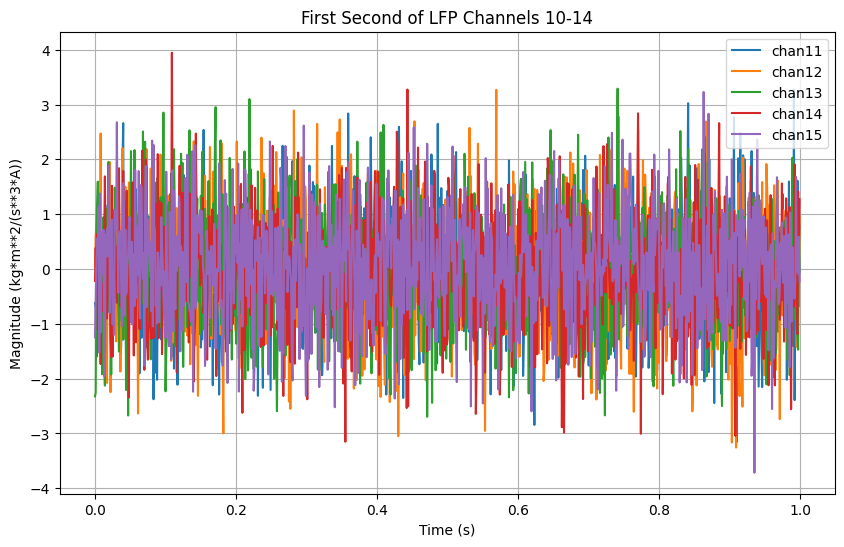

In [57]:
lfp = segment.analogsignals[0]
lfp_1s = lfp.time_slice(0*pq.s, 1*pq.s)
lfp_subset = lfp_1s[:, 10:15]

plt.figure(figsize=(10, 6))

for i in range(lfp_subset.shape[1]):
    plt.plot(lfp_subset.times.magnitude, lfp_subset.magnitude[:, i],
             label=lfp_subset.array_annotations['channel_names'][i])

plt.xlabel(f"Time ({lfp_subset.times.dimensionality.simplified})")
plt.ylabel(f"Magnitude ({lfp_subset.dimensionality.simplified})")
plt.title("First Second of LFP Channels 10-14")
plt.legend()
plt.grid(True)
plt.show()

## Visualizing Trial Data (Bonus)

Now that the recording is cut into aligned trial segments, we can produce the most common visualization in systems neuroscience: a **raster plot**, which shows the spike times of one unit stacked across all trials. We can also compute a **trial-averaged signal** (i.e., the mean LFP across trials).

**Exercise**: Collect the first spike train (`spiketrains[0]`) from every trial segment and plot a raster. For each trial `i`, use `ax.plot(st.rescale('ms').magnitude, [i]*len(st), '|k', markersize=6)`. Add axis labels, a title, and a vertical dashed red line at `x=0` to mark the reference event.

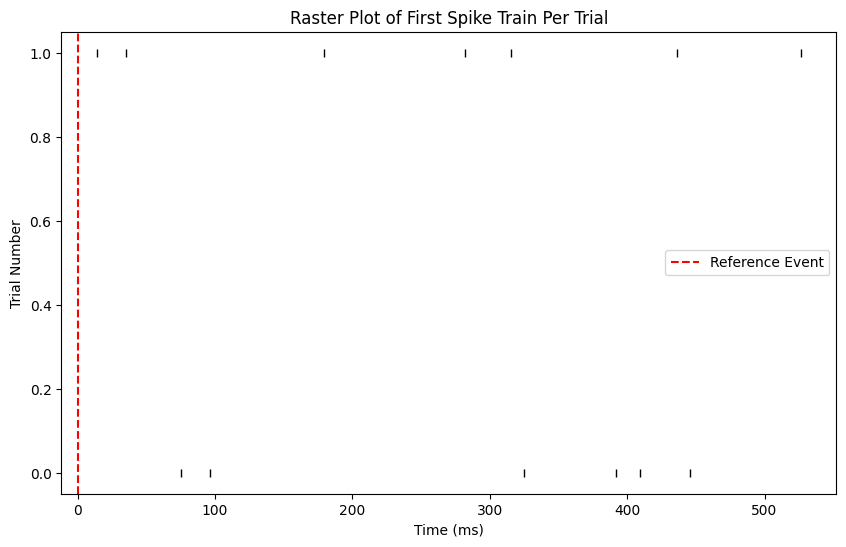

In [58]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

for i, seg in enumerate(trial_segments):
    st = seg.spiketrains[0]
    ax.plot(st.rescale('ms').magnitude, [i] * len(st), '|k', markersize=6)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Trial Number')
ax.set_title('Raster Plot of First Spike Train Per Trial')
ax.axvline(x=0, color='r', linestyle='--', label='Reference Event')
ax.legend()
plt.show()

**Exercise**: Use `time_slice` to extract only the first 300 ms after the reference event (`0*pq.ms` to `300*pq.ms`) from the first spike train of the first trial segment. Print `len` before and after slicing.

In [60]:
st = trial_segments[0].spiketrains[0]
print(f"Length before slicing: {len(st)}")

st_sliced = st.time_slice(0*pq.ms, 300*pq.ms)
print(f"Length after slicing: {len(st_sliced)}")

Length before slicing: 6
Length after slicing: 2


**Exercise**: Compute and plot the trial-averaged LFP of channel 0. Collect `seg.analogsignals[0][:, 0].magnitude` from every trial segment, compute `np.mean(..., axis=0)`, and plot it against the time axis taken from the first trial segment. Add axis labels and a vertical dashed red line at `x=0` marking the reference event.

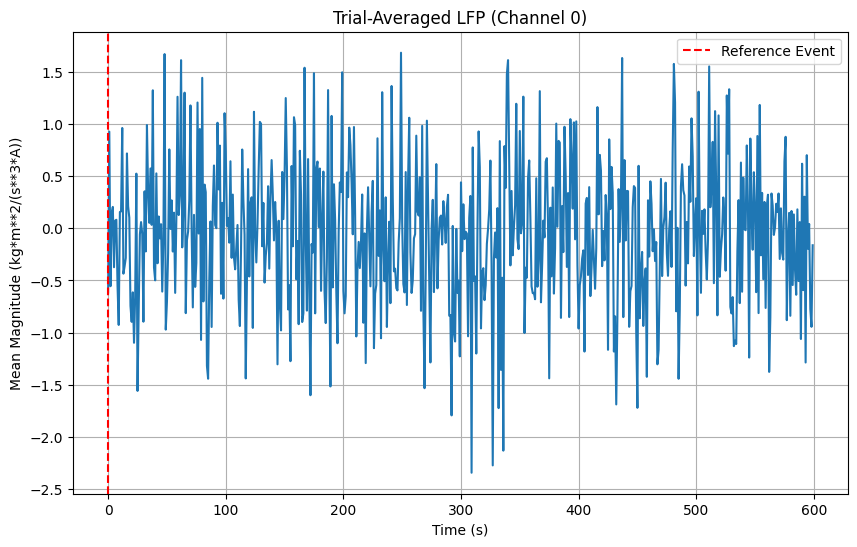

In [61]:
lfp_trials = [seg.analogsignals[0][:, 0].magnitude for seg in trial_segments]
mean_lfp = np.mean(lfp_trials, axis=0)

time_axis = trial_segments[0].analogsignals[0].times.rescale('ms')

plt.figure(figsize=(10, 6))
plt.plot(time_axis.magnitude, mean_lfp)
plt.axvline(x=0, color='r', linestyle='--', label='Reference Event')

plt.xlabel(f"Time ({time_axis.dimensionality.simplified})")
plt.ylabel(f"Mean Magnitude ({trial_segments[0].analogsignals[0].dimensionality.simplified})")
plt.title("Trial-Averaged LFP (Channel 0)")
plt.legend()
plt.grid(True)
plt.show()

> **Note**: This section uses `nixio`, which requires a compiled HDF5 library. It runs correctly with the course's pixi environment but **cannot run in JupyterLite** (browser-based execution). Run these cells with a local kernel.

## From Neo to NIX: Storing Neuroscience Data

**NIX** is an HDF5-based file format purpose-built for neuroscience data. Its central idea is an explicit *object model* that keeps data and its description inseparable:

- A **`File`** contains one or more **`Block`** objects, each representing a recording session or dataset. (Note: This is **not** a Neo Block!)
- Each `Block` contains **`DataArray`** objects. A `DataArray` wraps a numpy array and stores its physical `unit` and a human-readable `label`.
- Every axis of a `DataArray` is described by a **dimension descriptor**: a `SampledDimension` for regularly sampled axes (e.g. a time axis at 1 kHz), or a `SetDimension` for categorical axes (e.g. channel names).

This object model maps naturally onto Neo: when `neo.io.NixIO` writes a Neo `Block` to disk it creates a NIX file containing a NIX `Block`, with every `AnalogSignal` channel stored as its own `DataArray` with proper dimension descriptors. Neo's UUID-based internal naming is designed for round-tripping; when you write your own analysis results to NIX you are free to use clean, human-readable names.

The exercises below first introduce the raw `nixio` API, then show how to peek inside a Neo-generated NIX file and how to store analysis results with descriptive metadata. As an outlook, besides storing Neo objects in the NIX file format, you can store additional, non-electrophysiology data in the NIX file using `nixio`, such as behavioral data or analysis results.

| Code | Description |
| --- | --- |
| `nixio.File.open('f.nix', nixio.FileMode.Overwrite)` | Create a new file (overwrites if it exists) |
| `nixio.File.open('f.nix', nixio.FileMode.ReadOnly)` | Open an existing file for reading |
| `nixio.File.open('f.nix', nixio.FileMode.ReadWrite)` | Open an existing file for reading and writing |
| `with nixio.File.open(...) as nf:` | Context manager — always use this form to ensure the file is closed |
| `nf.blocks` | List of all blocks in the file |
| `blk = nf.create_block('name', 'type')` | Create a `Block` inside the file |
| `da = blk.create_data_array('name', 'type', data=arr, unit='mV', label='voltage')` | Create a `DataArray` from a numpy array |
| `blk.data_arrays[0]` | Access a `DataArray` by index |
| `da[:]` | Read all data back as a numpy array |
| `da.shape`, `da.unit`, `da.label` | Properties of a `DataArray` |
| `da.append_sampled_dimension(dt, unit='s', label='time')` | Attach a regularly-sampled axis (e.g. a time axis) |
| `da.append_set_dimension(labels=['Fz', 'Cz', 'Pz'])` | Attach a categorical axis with explicit labels |
| `da.dimensions[0].dimension_type` | Type of the first axis descriptor |
| `da.dimensions[0].sampling_interval` | Sampling interval of a `SampledDimension` |
| `da.dimensions[1].labels` | Category labels of a `SetDimension` |

In [1]:
import nixio

**Exercise**: Create a file `'recording.nix'` in `Overwrite` mode using the context manager. Inside the `with` block, print `nf.blocks` to confirm the file starts empty, then create a block named `'session'` with type `'nix.session'`. Print `nf.blocks` again to confirm the block was added.

In [2]:
with nixio.File.open('recording.nix', nixio.FileMode.Overwrite) as nf:
    
    print(f"Blocks at start: {nf.blocks}")
    
    nf.create_block('session', 'nix.session')
    
    print(f"Blocks after creation: {nf.blocks}")

Blocks at start: []
Blocks after creation: [Block: {name = session, type = nix.session}]


**Exercise**: Reopen `'recording.nix'` in `ReadWrite` mode. Retrieve the block (`nf.blocks[0]`). Create a `DataArray` named `'voltage'` from the 1D sine-wave signal defined in the cell below, with `unit='mV'` and `label='membrane voltage'`. Append a `SampledDimension` with `sampling_interval=0.001`, `unit='s'`, and `label='time'`. Print `da.shape`.

In [5]:
import numpy as np
dt = 0.001
t = np.arange(0, 1, dt)
signal = np.sin(2 * np.pi * 5 * t)


with nixio.File.open('recording.nix', nixio.FileMode.ReadWrite) as nf:
    blk = nf.blocks[0]
    
    # Create DataArray
    da = blk.create_data_array('voltage', 'nix.sampled', data=signal, unit='mV', label='membrane voltage')
    
    # Append SampledDimension
    da.append_sampled_dimension(sampling_interval=dt, unit='s', label='time')
    
    print(f"DataArray shape: {da.shape}")

DataArray shape: (1000,)


**Exercise**: Reopen `'recording.nix'` in `ReadOnly` mode. Access the first block and first `DataArray`. Print `da.name`, `da.unit`, `da.label`, and `da.shape`. Then print the first 5 values with `da[:5]`.

In [6]:
with nixio.File.open('recording.nix', nixio.FileMode.ReadOnly) as nf:
    blk = nf.blocks[0]
    da = blk.data_arrays[0]
    
    print(f"Name: {da.name}")
    print(f"Unit: {da.unit}")
    print(f"Label: {da.label}")
    print(f"Shape: {da.shape}")
    print(f"First 5 values: {da[:5]}")

Name: voltage
Unit: mV
Label: membrane voltage
Shape: (1000,)
First 5 values: [0.         0.03141076 0.06279052 0.09410831 0.12533323]


**Exercise**: Reopen `'recording.nix'` in `ReadOnly` mode. Read `da.dimensions[0].dimension_type` and `da.dimensions[0].sampling_interval` for the voltage `DataArray`. How does the sampling interval relate to the `dt` used when creating the signal?

In [7]:
with nixio.File.open('recording.nix', nixio.FileMode.ReadOnly) as nf:
    da = nf.blocks[0].data_arrays['voltage']
    dim = da.dimensions[0]
    
    print(f"Dimension type: {dim.dimension_type}")
    print(f"Sampling interval: {dim.sampling_interval} {dim.unit}")
    print(f"Relationship to dt: The sampling interval is equal to dt ({dim.sampling_interval} == 0.001)")

Dimension type: DimensionType.Sample
Sampling interval: 0.001 s
Relationship to dt: The sampling interval is equal to dt (0.001 == 0.001)


**Exercise**: Reopen `'recording.nix'` in `ReadWrite` mode. Create a second `DataArray` named `'eeg'` from the 2D EEG-like array defined in the cell below (shape `(1000, 3)`, unit `'uV'`, label `'EEG signal'`). Attach a `SampledDimension` (1 ms interval, unit `'s'`, label `'time'`) for the first axis and a `SetDimension` with `labels=['Fz', 'Cz', 'Pz']` for the second. Print `da2.shape`.

In [ ]:
eeg_data = np.random.normal(size=(1000, 3))

with nixio.File.open('recording.nix', nixio.FileMode.ReadWrite) as nf:
    blk = nf.blocks[0]
    
    da2 = blk.create_data_array('eeg', 'nix.sampled', data=eeg_data, unit='uV', label='EEG signal')
    
    
    da2.append_sampled_dimension(sampling_interval=0.001, unit='s', label='time')
    
    
    da2.append_set_dimension(labels=['Fz', 'Cz', 'Pz'])
    
    print(f"da2 shape: {da2.shape}")

da2 shape: (1000, 3)


**Exercise**: Reopen `'recording.nix'` in `ReadOnly` mode. Access the second `DataArray` (`blk.data_arrays[1]`). Print the `dimension_type` and `sampling_interval` of the first dimension, and the `dimension_type` and `labels` of the second dimension. Confirm the channel names survived the round trip.

In [ ]:
with nixio.File.open('recording.nix', nixio.FileMode.ReadOnly) as nf:
    blk = nf.blocks[0]
    da2 = blk.data_arrays[1]
    
    
    dim1 = da2.dimensions[0]
    print(f"Dimension 1 type: {dim1.dimension_type}")
    print(f"Dimension 1 sampling interval: {dim1.sampling_interval} {dim1.unit}")
    
    
    dim2 = da2.dimensions[1]
    print(f"Dimension 2 type: {dim2.dimension_type}")
    print(f"Dimension 2 labels: {dim2.labels}")
    
    if list(dim2.labels) == ['Fz', 'Cz', 'Pz']:
        print("Confirmation: Channel names survived the round trip!")

Dimension 1 type: DimensionType.Sample
Dimension 1 sampling interval: 0.001 s
Dimension 2 type: DimensionType.Set
Dimension 2 labels: ('Fz', 'Cz', 'Pz')
Confirmation: Channel names survived the round trip!


**Exercise**: Open `data/dataset.nix'` in `ReadOnly` mode with raw `nixio`. Access the first block with `nf.blocks[0]`. Print the block's `name`, the total number of `DataArrays`, and the number of `MultiTags`. Then print the `name` of `blk.data_arrays[0]`. What naming scheme does NixIO use?

In [19]:
with nixio.File.open('D:\ANI\day2\dataset.nix', nixio.FileMode.ReadOnly) as nf:
    blk = nf.blocks[0]
    
    print(f"Block Name: {blk.name}")
    print(f"Number of DataArrays: {len(blk.data_arrays)}")
    print(f"Number of MultiTags: {len(blk.multi_tags)}")
    print(f"First DataArray Name: {blk.data_arrays[0].name}")


Block Name: neo.block.0d83ec5461364701ac6b3a11dcfa00f4
Number of DataArrays: 111
Number of MultiTags: 9
First DataArray Name: neo.analogsignal.f39a43150e8d465d9585770139330737.0


<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Asus\AppData\Local\Temp\ipykernel_11304\126436006.py:1: SyntaxWarning: invalid escape sequence '\A'
  with nixio.File.open('D:\ANI\day2\dataset.nix', nixio.FileMode.ReadOnly) as nf:


NixIO uses UUID-based names (`neo.analogsignal.<hash>.<channel_index>`) and stores one `DataArray` per channel. This internal convention is designed for round-tripping through Neo — it is not meant to be navigated directly with `nixio`. When *you* create a NIX file for your own results, you can choose clean, descriptive names and store multi-channel data as a single 2-D `DataArray` with a `SetDimension` for the channel axis.

The cells below rebuild the `trial_segments` and `mean_lfp` variables used in the previous section, so this section can be run independently.

In [25]:
# reload block
import neo
import quantities as pq
from neo.utils import add_epoch , cut_segment_by_epoch
with neo.NixIO('D:\ANI\day2\dataset.nix', mode='ro') as io:
    block = io.read_block()
segment = block.segments[0]

# rebuild trial cuts (correct events, -100 ms to +500 ms window)
events        = segment.events[0]
correct_mask  = events.array_annotations['performance_in_trial_str'] == 'correct_trial'
correct_ev    = events[correct_mask]
epoch         = add_epoch(segment, event1=correct_ev,
                          pre=-100*pq.ms, post=500*pq.ms,
                          attach_result=False, name='analysis_epochs')
trial_segments = cut_segment_by_epoch(segment, epoch, reset_time=True)

# compute trial-averaged LFP (channel 0)
lfp_trials = [seg.analogsignals[0][:, 0].magnitude for seg in trial_segments]
mean_lfp   = np.mean(lfp_trials, axis=0)
n_trials   = len(trial_segments)
dt_s       = float(trial_segments[0].analogsignals[0].sampling_period
                   .rescale('s').magnitude)
print(f'mean_lfp shape: {mean_lfp.shape}, dt={dt_s} s, n_trials={n_trials}')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Asus\AppData\Local\Temp\ipykernel_11304\3846462377.py:5: SyntaxWarning: invalid escape sequence '\A'
  with neo.NixIO('D:\ANI\day2\dataset.nix', mode='ro') as io:


mean_lfp shape: (600, 1), dt=0.001 s, n_trials=2


**Exercise**: Create a file `'analysis_results.nix'` in `Overwrite` mode. Inside it, create a block named `'analysis'`. Store `mean_lfp` as a `DataArray` named `'mean LFP'` with `unit='uV'` and `label='LFP channel 0'`. Append a `SampledDimension` using `dt_s` as the sampling interval (unit `'s'`, label `'time'`). Print `da.shape`.

In [26]:
with nixio.File.open('analysis_results.nix', nixio.FileMode.Overwrite) as nf:
    
    block = nf.create_block('analysis', 'nix.analysis')
    
   
    da = block.create_data_array('mean LFP', 'nix.sampled', data=mean_lfp, unit='uV', label='LFP channel 0')
    
   
    da.append_sampled_dimension(sampling_interval=dt_s, unit='s', label='time')
    
    print(f"DataArray shape: {da.shape}")

DataArray shape: (600, 1)


**Exercise**: Reopen `'analysis_results.nix'` in `ReadWrite` mode. Create a metadata `Section` named `'analysis info'` with type `'nix.metadata'`. Add three properties: `'analysis_type'` (`'trial-averaged LFP'`), `'n_trials'` (the integer `n_trials`), and `'source_file'` (`'data/dataset.nix'`). Link the section to the `DataArray` via `da.metadata = sec`.

In [27]:
with nixio.File.open('analysis_results.nix', nixio.FileMode.ReadWrite) as nf:
    blk = nf.blocks['analysis']
    da = blk.data_arrays['mean LFP']

  
    sec = nf.create_section('analysis info', 'nix.metadata')

    
    sec['analysis_type'] = 'trial-averaged LFP'
    sec['n_trials'] = int(n_trials)
    sec['source_file'] = 'data/dataset.nix'

  
    da.metadata = sec

    print(f"Metadata section '{sec.name}' created and linked to DataArray '{da.name}'.")
    print("Properties added:", [p.name for p in sec.props])

Metadata section 'analysis info' created and linked to DataArray 'mean LFP'.
Properties added: ['analysis_type', 'n_trials', 'source_file']


**Exercise**: Reopen `'analysis_results.nix'` in `ReadOnly` mode. Read back the `DataArray` and print its `name`, `shape`, `unit`, and the sampling interval of its first dimension. Then iterate over `da.metadata.props` and print each property name and its first value.

In [28]:
with nixio.File.open('analysis_results.nix', nixio.FileMode.ReadOnly) as nf:
    blk = nf.blocks['analysis']
    da = blk.data_arrays['mean LFP']

    
    print(f"DataArray Name: {da.name}")
    print(f"Shape: {da.shape}")
    print(f"Unit: {da.unit}")
    
    
    dim = da.dimensions[0]
    print(f"Sampling Interval: {dim.sampling_interval} {dim.unit}")

    
    print("\nMetadata Properties:")
    if da.metadata:
        for prop in da.metadata.props:
            print(f"- {prop.name}: {prop.values[0]}")
    else:
        print("No metadata linked to this DataArray.")

DataArray Name: mean LFP
Shape: (600, 1)
Unit: uV
Sampling Interval: 0.001 s

Metadata Properties:
- analysis_type: trial-averaged LFP
- n_trials: 2
- source_file: data/dataset.nix
